GPU: True
original samples: [[  0.24       -20.         -20.        ]
 [  0.24       -20.         -19.46666667]
 [  0.24       -20.         -18.93333333]
 ...
 [ 12.          20.          18.93333333]
 [ 12.          20.          19.46666667]
 [ 12.          20.          20.        ]]


100%|███████████████████████████| 10000/10000 [04:42<00:00, 35.41it/s, Iter=1e+4, PDE_Loss=2.12e-03]


solve PDE Adam done!
Iter: 10100 PDE_Loss: 0.00035531423054635525
loss of ic0: tensor(0.0002, device='cuda:0', grad_fn=<MeanBackward0>) loss of boundary: tensor(2.2130e-05, device='cuda:0', grad_fn=<MeanBackward0>) loss of equation: tensor(0.0001, device='cuda:0', grad_fn=<AddBackward0>)
Iter: 10200 PDE_Loss: 0.0003449447685852647
loss of ic0: tensor(0.0002, device='cuda:0', grad_fn=<MeanBackward0>) loss of boundary: tensor(2.0521e-05, device='cuda:0', grad_fn=<MeanBackward0>) loss of equation: tensor(0.0001, device='cuda:0', grad_fn=<AddBackward0>)
Iter: 10300 PDE_Loss: 0.0003042581374756992
loss of ic0: tensor(0.0002, device='cuda:0', grad_fn=<MeanBackward0>) loss of boundary: tensor(2.0483e-05, device='cuda:0', grad_fn=<MeanBackward0>) loss of equation: tensor(0.0001, device='cuda:0', grad_fn=<AddBackward0>)
Iter: 10400 PDE_Loss: 0.0002601429296191782
loss of ic0: tensor(0.0002, device='cuda:0', grad_fn=<MeanBackward0>) loss of boundary: tensor(1.4811e-05, device='cuda:0', grad_fn=<

/root/ewsampling_barrier.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
/root/ewsampling_barrier.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
/root/ewsampling_barrier.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y_f = torch.tensor(X_f[:, 2:3], requires_grad=True).float().to(device)


MMPDE_Adam Iter 100 Loss 1.4083515e-05 loss of equ 1.4083515e-05
MMPDE_Iter 10, Time: 11.1713
MMPDE_Adam Iter 200 Loss 5.836283e-06 loss of equ 5.836283e-06
MMPDE_Iter 10, Time: 11.1361
MMPDE_Adam Iter 300 Loss 3.4052914e-06 loss of equ 3.4052914e-06
MMPDE_Iter 10, Time: 11.1352
MMPDE_Adam Iter 400 Loss 2.3166763e-06 loss of equ 2.3166763e-06
MMPDE_Iter 10, Time: 11.1334
MMPDE_Adam Iter 500 Loss 1.7218549e-06 loss of equ 1.7218549e-06
MMPDE_Iter 10, Time: 11.1257
MMPDE_Adam Iter 600 Loss 1.3562185e-06 loss of equ 1.3562185e-06
MMPDE_Iter 10, Time: 11.1226
MMPDE_Adam Iter 700 Loss 1.1111572e-06 loss of equ 1.1111572e-06
MMPDE_Iter 10, Time: 11.1311
MMPDE_Adam Iter 800 Loss 9.3514234e-07 loss of equ 9.3514234e-07
MMPDE_Iter 10, Time: 11.1256
MMPDE_Adam Iter 900 Loss 8.0177574e-07 loss of equ 8.0177574e-07
MMPDE_Iter 10, Time: 11.1212
MMPDE_Adam Iter 1000 Loss 6.966715e-07 loss of equ 6.966715e-07
MMPDE_Iter 10, Time: 11.1280
MMPDE_Adam Iter 1100 Loss 6.1147585e-07 loss of equ 6.1147585e-

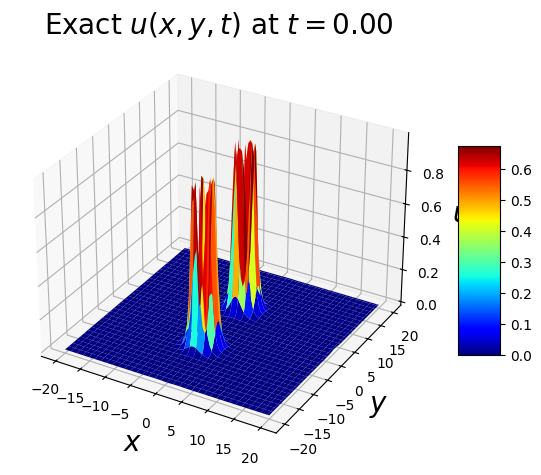

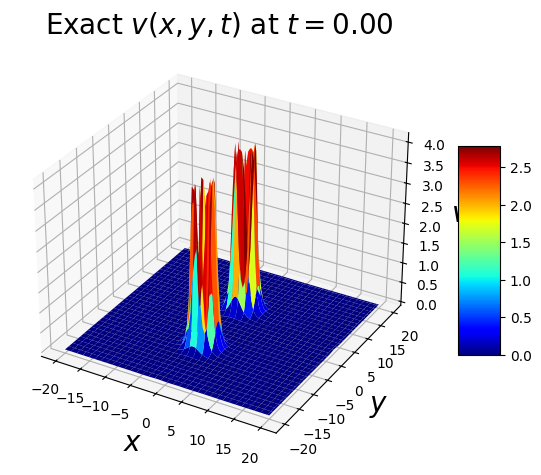

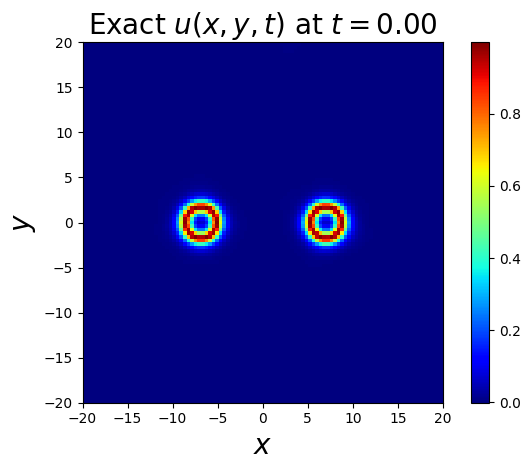

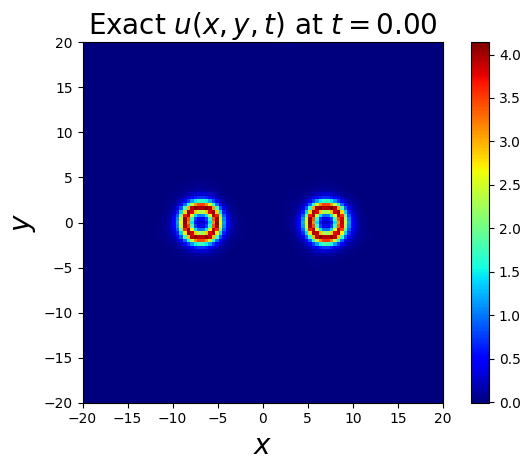

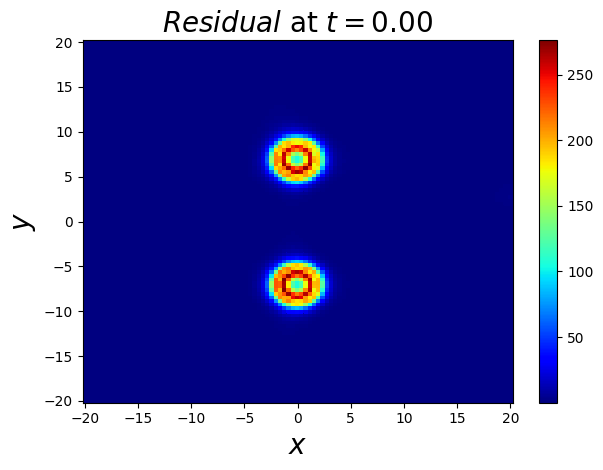

In [1]:
import os
import time
import numpy as np
import torch
from matplotlib import pyplot as plt, gridspec
from torch import nn
from torch.autograd import Variable
from tqdm import tqdm, trange
#import PDE_Generalbs as GBS
from ewsampling_barrier import sampling_MMPDE
import scipy.io
from scipy.stats import norm
'''
solving 1-D burgers equation with adaptive sampling (solving the MMPDE)
'''


os.environ['CUDA_VISIBLE_DEVICES'] = '1'
use_gpu = torch.cuda.is_available()
print('GPU:', use_gpu)

def is_cuda(data):
    if use_gpu:
        data = data.cuda()
    return data



def ini_sample(M, N, P):
    """
    生成在区域 [0,12]x[-20,20]x[-20,20] 上的网格点。

    参数:
    M (int): t轴 [0,1] 区间上的点数。
    N (int): x轴 [0,1] 区间上的点数。
    P (int): y轴 [0,1] 区间上的点数。

    返回:
    torch.Tensor: 形状为 (M*N*P, 3) 的张量，每行表示一个点的 (t, x, y) 坐标。
    """
    # 生成各个维度的坐标
    t = np.linspace(0, 12, M+1)
    t = t[1:]
    x = np.linspace(-20, 20, N)
    y = np.linspace(-20, 20, P)
    
    # 生成三维网格
    T, X, Y = np.meshgrid(t, x, y, indexing='ij')
    
    # 将网格点转换为坐标数组
    grid = np.column_stack((T.ravel(), X.ravel(), Y.ravel()))
    print('original samples:', grid)
    
    # 转换为PyTorch张量
    temp = torch.from_numpy(grid).float()  # numpy to tensor float32
    
    # 如果使用GPU，将张量移到GPU上
    if use_gpu:
        temp = temp.cuda()
        
    return temp



def sampling_for_equ(grid_tensor):
    """
    去除边界值和初值（三维情况）

    参数:
    grid_tensor (torch.Tensor): 形状为 (M*N*P, 3) 的网格点张量

    返回:
    torch.Tensor: 过滤后的张量
    """
    # 首先检查输入维度
    if grid_tensor.shape[1] != 3:
        raise ValueError(f"Expected grid_tensor with 3 columns [t,x,y], but got shape {grid_tensor.shape}")

    # 删除初始时刻的点
    grid_tensor = grid_tensor[Nbc:, :]

    # 获取x和y坐标值
    x_values = grid_tensor[:, 1]
    y_values = grid_tensor[:, 2]

    # 创建非边界点的布尔掩码
    mask_x = ~(torch.isclose(x_values, torch.tensor(-20.0).to(x_values.device), atol=1e-8) |
               torch.isclose(x_values, torch.tensor(20.0).to(x_values.device), atol=1e-8))
    
    mask_y = ~(torch.isclose(y_values, torch.tensor(-20.0).to(y_values.device), atol=1e-8) |
               torch.isclose(y_values, torch.tensor(20.0).to(y_values.device), atol=1e-8))

    # 组合掩码
    mask = mask_x & mask_y

    return grid_tensor[mask]
class FCNet(nn.Module):
    """FC Neural Network."""
    def __init__(self, layers, w_init=True, active=nn.Tanh()):
        super(FCNet, self).__init__()

        # Parameters
        self.depth = len(layers) - 1
        self.active = active

        # Layers list
        layer_list = list()
        for layer in range(self.depth - 1):
            layer_list.append(
                nn.Linear(layers[layer], layers[layer+1])
            )
            layer_list.append(active)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        # Net
        self.main = nn.Sequential(*layer_list)

        # Initialize parameters
        if w_init:
            self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1)
                m.bias.data.zero_()

    def forward(self, x):
        return self.main(x)

class Net_u1(nn.Module):
    """Deep Residual Learning for Image Recognition[arXiv:1512.03385]."""
    def __init__(self, backbone_layers, residual_layers):
        super(Net_u1, self).__init__()

        # Check input and output
        if len(residual_layers) > 0 and backbone_layers[-2] != residual_layers[-1]:
            raise AssertionError("Output size of backbone net and residual net do not match!")
        self.iter = 0
        # layers
        self.res_layers = residual_layers
        self.backbone_layers = backbone_layers

        # Input layer
        self.input_layer = FCNet(self.backbone_layers[:2])

        # Backbone network.
        self.backbone = FCNet(self.backbone_layers[1:-1])

        # Residual network.
        self.residual = self._build_resnet()

        # Output layer
        self.output = FCNet(self.backbone_layers[-2:])

    def _build_resnet(self):
        """Build Res Connection."""
        if len(self.res_layers) == 0:
            return None
        layer_list = list()
        layer_list.append(nn.Linear(self.backbone_layers[1], self.res_layers[0]))
        layer_list.append(nn.Tanh())

        if len(self.res_layers) <= 1:
            return nn.Sequential(*layer_list)

        for layer in range(1, len(self.res_layers)-1):
            layer_list.append(nn.Linear(self.res_layers[layer], self.res_layers[layer+1]))
            layer_list.append(nn.Tanh())

        return nn.Sequential(*layer_list)

    def forward(self, x):
        x = self.input_layer(x)
        b = self.backbone(x)

        if self.residual is not None:
            r = self.residual(x)
            x = r + b
        x = x + b

        return self.output(x)

class Net_u(nn.Module):
    def __init__(self, layers):
        super(Net_u, self).__init__()
        self.layers = layers
        self.iter = 0
        self.activation = nn.Tanh()
        self.linear = nn.ModuleList([nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)])
        for i in range(len(layers) - 1):
            nn.init.xavier_normal_(self.linear[i].weight.data, gain=1.0)
            nn.init.zeros_(self.linear[i].bias.data)

    def forward(self, x):
        if not torch.is_tensor(x):
            x = torch.from_numpy(x)
        a = self.activation(self.linear[0](x))
        for i in range(1, len(self.layers) - 2):
            z = self.linear[i](a)
            a = self.activation(z)
        a = self.linear[-1](a)
        return a

from torch.autograd import grad, Variable  # 确保正确导入 grad 和 Variable

def PDE_loss_fun(x, train_U):
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    uv = train_U(x)
    u = uv[:, 0:1]
    v = uv[:, 1:2]

    # 对 u, v 分别求一阶导
    u_t = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 0:1]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 1:2]
    u_y = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 2:3]
    v_t = grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 0:1]
    v_x = grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 1:2]
    v_y = grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 2:3]

    # 对 u, v 的一阶导继续分别求二阶导
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]
    u_yy = grad(u_y, x, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 2:3]
    v_xx = grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0][:, 1:2]
    v_yy = grad(v_y, x, grad_outputs=torch.ones_like(v_y), create_graph=True)[0][:, 2:3]

    f_u = u_t - v
    f_v = v_t - u_xx - u_yy + torch.sin(u)
    return f_u, f_v
def sech(x):
    return 1/np.cosh(x)
    
def exact_u(x):
    u = 4 * (np.arctan(np.exp(4 - np.sqrt((x[:, 1]**2 / 0.436**2) + ((x[:, 2] + 7)**2 / 0.436**2)))) + np.arctan(np.exp(4 - np.sqrt((x[:, 1]**2 / 0.436**2) + ((x[:, 2] - 7)**2 / 0.436**2)))))
    return u[:, None]


def exact_v(x):
    # 参数定义
    factor = 4.13
    scale = 0.436
    
    # 计算第一部分的 sech 函数
    term1 = sech(4 - np.sqrt((x[:, 1]**2) / (scale**2) + ((x[:, 2] + 7)**2) / (scale**2)))
    part1 = factor * term1
    
    # 计算第二部分的 sech 函数
    term2 = sech(4 - np.sqrt((x[:, 1]**2) / (scale**2) + ((x[:, 2] - 7)**2) / (scale**2)))
    part2 = factor * term2
    v = part1 + part2
    return v[:, None]

def exact_uv(x):
    u = exact_u(x)
    v = exact_v(x)
    return np.hstack((u, v))

def exact_ub(x):
    u = 0*x[:, 2]
    return u[:, None]


def exact_vb(x):
    v= 0*x[:, 2]
    return v[:, None]

def exact_uvb(x):
    u = exact_ub(x)
    v = exact_vb(x)
    return np.hstack((u, v))


'''
def PDE_ic_fun(x, train_U):
    if not x.requires_grad:
        x = torch.autograd.Variable(x, requires_grad=True)
    
    # 计算 u 和其梯度
    u = train_U(x)
    d = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_t = d[0][:, 0].unsqueeze(-1)  # 对 t 的偏导数，形状为 (n, 1)

    # 筛选出 t=0 的行
    mask = (x[:, 0] == 0)  # 筛选 t==0 的布尔掩码
    u_t_t0 = u_t[mask]     # 应用掩码筛选
    s = x[:, 1]
    y = x[:, 2]
    s = s[mask]
    y = y[mask]
    # 参数定义
    factor = 4.13
    scale = 0.436
    
    # 计算第一部分的 sech 函数
    term1 = torch.cosh(4 - torch.sqrt((s**2) / (scale**2) + ((y + 7)**2) / (scale**2))).reciprocal()
    part1 = factor * term1
    
    # 计算第二部分的 sech 函数
    term2 = torch.cosh(4 - torch.sqrt((s**2) / (scale**2) + ((y - 7)**2) / (scale**2))).reciprocal()
    part2 = factor * term2
    
    f=u_t_t0 - part1 - part2
    return f
def PDE_ic_fun(x, train_U):
    if not x.requires_grad:
        x = Variable(x, requires_grad=True)
    x = x[x[:, 0] == 0]
    u = train_U(x)
    d = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)
    u_t = d[0][:, 0].unsqueeze(-1)
    s = x[:, 1]
    y = x[:, 2]
    
    # 参数定义
    factor = 4.13
    scale = 0.436
    
    # 计算第一部分的 sech 函数
    term1 = torch.cosh(4 - torch.sqrt((s**2) / (scale**2) + ((y + 7)**2) / (scale**2))).reciprocal()
    part1 = factor * term1
    
    # 计算第二部分的 sech 函数
    term2 = torch.cosh(4 - torch.sqrt((s**2) / (scale**2) + ((y - 7)**2) / (scale**2))).reciprocal()
    part2 = factor * term2
    
    f=u_t - part1 - part2
    return f
'''
class Model:
    def __init__(self, net, x_bc, u_bc,x_ic,u_ic,
                 PDE_loss_fun,
                 x_test, 
                 nu):

        self.x_ic_s = None
        self.x_bc_s = None
        self.x_f_s = None
        self.s_collect = []

        self.optimizer_LBGFS = None
        self.net = net

        self.x_bc = x_bc
        self.u_bc = u_bc

        self.x_ic = x_ic
        self.u_ic = u_ic

        self.x_sample = None

        self.PDE_loss_fun = PDE_loss_fun   #equation loss
        self.x_test = x_test
        #self.u_test_exact = u_test_exact
        
        self.nu = nu

        self.start_loss_collect = False
        self.x_label_loss_collect = []
        self.x_f_loss_collect = []
        self.x_test_estimate_collect = []

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)
        
    def true_loss(self, loss_e, loss_ic, loss_bc):
        return (torch.exp(-self.x_f_s.detach()) * loss_e + torch.exp(-self.x_ic_s.detach()) * loss_ic +
                torch.exp(-self.x_bc_s.detach()) * loss_bc)

    # compute backward loss
    def epoch_loss(self):

        x_f = sampling_for_equ(self.x_sample)   #delete initial and boundaries
        #print('samples for equ:', x_f)
        loss_equationu , loss_equationv = self.PDE_loss_fun(x_f, self.train_U) 
        loss_equation = torch.mean(loss_equationu ** 2) + torch.mean(loss_equationv ** 2)
        loss_ic0 = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)
        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)
        # if self.start_loss_collect:
        #     self.x_f_loss_collect.append([self.net.iter, loss_equation.item()])
        #     self.x_label_loss_collect.append([self.net.iter, loss_label.item()])
        return loss_equation, loss_ic0, loss_bc

    # compute backward loss
    def LBGFS_epoch_loss(self):
        self.optimizer_LBGFS.zero_grad()
        #x_f = self.x_sample
        x_f = sampling_for_equ(self.x_sample)  # delete initial and boundaries
        loss_equationu,loss_equationv = self.PDE_loss_fun(x_f, self.train_U) 
        loss_equation = torch.mean(loss_equationu ** 2) + torch.mean(loss_equationv ** 2)
        loss_ic = torch.mean((self.train_U(self.x_ic) - self.u_ic) ** 2)
        loss_bc = torch.mean((self.train_U(self.x_bc) - self.u_bc) ** 2)

        # if self.start_loss_collect:
        #     self.x_f_loss_collect.append([self.net.iter, loss_equation.item()])
        #     self.x_label_loss_collect.append([self.net.iter, loss_label.item()])

        loss = self.true_loss(loss_equation, loss_ic, loss_bc)
        loss.backward(retain_graph=True)
        self.net.iter += 1
        if self.net.iter % 100  == 0:
           print('Iter:', self.net.iter, 'PDE_Loss:', loss.item())
           print('loss of ic0:', loss_ic,  'loss of boundary:', loss_bc ,'loss of equation:', loss_equation)

        return loss

    def evaluate(self):
        pred = self.train_U(self.x_test).cpu().detach().numpy()
        print('predict:', pred)
        #exact = self.u_test_exact.cpu().detach().numpy()
        #print('exact:', exact)
        error = np.linalg.norm(pred - exact, 2) / np.linalg.norm(exact, 2)
        return error  #function  L_2 error


    def run_AM(self):

        for move_count in range(M_num):
            self.optimizer_LBGFS = torch.optim.LBFGS(self.net.parameters(), lr=lbgfs_lr,
                                                     max_iter=lbgfs_iter)
            optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=adam_lr)
            pbar = trange(adam_iter, ncols=100)


            # extract initial points from samples
            #t_zero_mask = torch.isclose(self.x_sample[:, 0], torch.tensor(0.0))
            #self.x_ic = self.x_sample[0:Nbc, :]
            #print('samples at $t_0$:', self.x_ic)
            #self.u_ic = ini_fun(self.x_ic)

            for i in pbar:
                optimizer_adam.zero_grad()
                loss_e, loss_ic, loss_bc = self.epoch_loss()
                loss = self.true_loss(loss_e, loss_ic, loss_bc)
                loss.backward(retain_graph=True)
                self.net.iter += 1
                optimizer_adam.step()
                            # === 添加 CUDA 同步 ===
                if torch.cuda.is_available():
                    torch.cuda.synchronize()  # 等待 GPU 计算完成
                pbar.set_postfix({'Iter': self.net.iter,
                                  'PDE_Loss': '{0:.2e}'.format(loss.item())
                                  })

            print('solve PDE Adam done!')
            self.optimizer_LBGFS.step(self.LBGFS_epoch_loss)
            print('solve PDE LBGFS done!')

            # model predict after one time sampling
            #error = self.evaluate()
            #print('change_counts', move_count, 'PDE_Test_L2error:', '{0:.2e}'.format(error))
            #self.x_test_estimate_collect.append([move_count, '{0:.2e}'.format(error)])


            ## adaptive sampling

            #u = self.train_U(self.x_sample)
            #print('the pde solution:', u)
            #if not self.x_sample.requires_grad:
            x_init = Variable(self.x_sample, requires_grad=True)
            #u = self.train_U(x_init)
            #print('u in learn pde:', u)
            #dx = torch.autograd.grad(u, x_init, grad_outputs=torch.ones_like(u), create_graph=True)[0]
            #grad_t = dx[:, [0]] #du/dt
            #grad_x = dx[:, [1]] #du/dx  size([,1])
            #print('dx:', grad_x)

            
            model_sampling = sampling_MMPDE(x_init, self.train_U, layers_p, lb, ub, self.nu, adam_iter_MM, lbgfs_iter_MM)
            self.x_sample = model_sampling.train()
            print(f"x_sample shape after MMPDE: {self.x_sample.shape}")
            if not self.x_sample.requires_grad:
                self.x_sample = Variable(self.x_sample, requires_grad=True)
            #print('new_sample', type(self.x_sample))
            self.nu = self.nu / 2

    def train(self):

        self.x_sample = ini_sample(Nic, Nbc, Nbc)  # initialize samples, x_sample.require_grad = false


        self.x_f_s = is_cuda(torch.tensor(0.).float())   # weight: loss of equation
        self.x_ic_s = is_cuda(torch.tensor(0.).float())  # weight: loss of initial condition
        self.x_bc_s = is_cuda(torch.tensor(0.).float())  # weight: loss of boundary condition
        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AM()

        elapsed = time.time() - start_time
        print('Training time: %.2f' % elapsed)

    
def draw_exact():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()

    pred_u = np.reshape(predict_np[:, 0], (len(t), len(x), len(y)))
    pred_v = np.reshape(predict_np[:, 1], (len(t), len(x), len(y)))

    time_idx = 0  
    plt.figure()
    plt.imshow(np.sin(0.5*pred_u[time_idx, :, :]), extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Exact $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('sg_u_exact.jpg')
    plt.show()

    plt.figure()
    plt.imshow(pred_v[time_idx, :, :], extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title(r'Exact $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('sg_v_exact.jpg')
    plt.show()


def draw_exact3d():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()

    pred_u = np.reshape(predict_np[:, 0], (len(t), len(x), len(y)))
    pred_v = np.reshape(predict_np[:, 1], (len(t), len(x), len(y)))

    time_idx = 0

    # meshgrid for 3D plotting
    X, Y = np.meshgrid(x, y, indexing='ij')

    # Plot for pred_u
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, np.sin(0.5 * pred_u[time_idx, :, :]), cmap='jet')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$y$', fontsize=20)
    ax.set_zlabel('$u$', fontsize=20)
    ax.set_title(r'Exact $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('sg_u_exact_3d.jpg')
    plt.show()

    # Plot for pred_v
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, pred_v[time_idx, :, :], cmap='jet')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$y$', fontsize=20)
    ax.set_zlabel('$v$', fontsize=20)
    ax.set_title(r'Exact $v(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('sg_v_exact_3d.jpg')
    plt.show()
    
def draw_residual():
    f_u, f_v = PDE_loss_fun(x_test, model.train_U)
    f_u = f_u.cpu().detach().numpy()
    f_v = f_v.cpu().detach().numpy()
    
    residual = np.sqrt(f_u**2 + f_v**2)
    
    residual = np.reshape(residual, (len(t), len(x), len(y)))

    time_idx = 0 
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    plt.figure()
    plt.pcolor(X, Y, residual[time_idx, :, :], cmap='jet')
    plt.colorbar()
    plt.xlabel('$x$', fontsize=20)
    plt.ylabel('$y$', fontsize=20)
    plt.title('$Residual$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('Burgers2D_residual.jpg')
    plt.show()


def draw_points(points, old_points=None):

    if old_points is not None:
        adds = old_points.cpu().detach().numpy()
        plt.plot(adds[:, [0]], adds[:, [1]], 'kx', markersize=4, clip_on=False)

    #points = points.cpu().detach().numpy()
    plt.plot(points[:, [0]], points[:, [1]], 'rx', markersize=1)
    plt.xlim(-0.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.title(r'points distribution', fontsize=20)
    plt.savefig('burgers_new_points.pdf')  # points distribution
    plt.show()


    xi_pred = points[:,1]   # predict of x:[Nic*Nbc,2]
    xi_new = xi_pred.reshape((Nic, Nbc), order='C')   # predict of x:[Nic,Nbc]


    x_t0 = xi_new[0, :].flatten()[:, None]
    plt.xlim(-1.1, 1.1)
    plt.ylim(-0.5, 0.5)
    plt.xlabel('$x$', fontsize=20)
    plt.plot(x_t0, 0 * x_t0, 'bo', markersize=1)
    plt.title(r'points distribution at $t_0$', fontsize=20)
    plt.savefig('burgers_new_points_t0.pdf')  # points distribution at initial time
    plt.show()

    x_t = xi_new[-1, :].flatten()[:, None]
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1, 1)
    plt.plot(x_t, 0 * x_t, 'bo', markersize=1)  # points distribution at end time
    plt.title(r'points distribution at $t_T$', fontsize=20)
    plt.xlabel('$x$', fontsize=20)
    plt.savefig('burgers_new_points_Tend.pdf')
    plt.show()



    ## plot the trajectaries of the left and right points (except the boundary points)
    xi_0 = xi_new[:, 50].flatten()[:, None]
    xi_end = xi_new[:, Nbc-10].flatten()[:, None]
    plt.plot(t.flatten()[:, None], xi_0, markersize=1)
    plt.plot(t.flatten()[:, None], xi_end, markersize=1)
    plt.title(r'points trajectaries of the left and right points', fontsize=20)
    plt.xlim(-0.1, 1.1)
    plt.ylim(-1, 1)
    plt.xlabel('$t$', fontsize=20)
    plt.ylabel('$x$', fontsize=20)
    plt.savefig('burgers_new_points.pdf')
    plt.show()

def draw_2d_points(points):
    """
    绘制二维偏微分方程 u(x, y, t) 在 t=0 时刻的点分布图。
    
    参数:
    points: numpy 数组，形状为 (N, 3)，每一行包含 [x, y, t]。
            只绘制 t=0 的点。
    """
    # 筛选 t=0 的点
    points_t0 = points[points[:, 0] == 0]  # 保留所有 t=0 的行

    # 提取 x 和 y 坐标
    x = points_t0[:, 1]  # 第 0 列是 x 坐标
    y = points_t0[:, 2]  # 第 1 列是 y 坐标

    # 绘制散点图
    plt.figure(figsize=(8, 6))  # 设置画布大小
    plt.scatter(x, y, c='b', s=10, label='Points at $t=0$')  # 绘制蓝色点，点大小为 10
    plt.xlabel('$x$', fontsize=20)  # 设置 x 轴标签
    plt.ylabel('$y$', fontsize=20)  # 设置 y 轴标签
    plt.title(r'2D Points Distribution at $t=0$', fontsize=20)  # 设置图标题
    plt.legend()  # 添加图例
    plt.grid(True)  # 显示网格
    plt.savefig('points_2d_t0.pdf')  # 保存图像为 PDF 文件
    plt.show()  # 显示图像
if __name__ == '__main__':
    lb = np.array([0.0, -20.0, -20.0]) #u[t,x]
    ub = np.array([12.0, 20.0, 20.0])

    layers_u = [3, 40, 40, 40, 40, 2]
    net = is_cuda(Net_u1([3, 20, 20, 20, 20,20, 2], [20, 20]))
    

    adam_iter, lbgfs_iter = 10000, 5000
    adam_lr, lbgfs_lr = 0.001, 0.05

    adam_iter_MM, lbgfs_iter_MM = 2000, 0

    model_type = 1  # 0:baseline 1:AM

    nu = 0.1

    M_num = 1  # number of moving samples

    layers_p = [3, 20, 20,20, 20, 20, 20, 20,20, 2]  # layers of the sampling network

    T = 12

    ##### training points

    ## number of training points
    Nic = 50  # number of t
    Nbc = 76  # number of x


    #初始条件    
    x_ic_np = np.hstack((np.zeros((Nic**2, 1)), np.random.uniform(-20, 20, (Nic**2, 1)), np.random.uniform(-20, 20, (Nic**2, 1))))
    u_ic_np = exact_uv(x_ic_np)
    
    x_ic = is_cuda(torch.from_numpy(x_ic_np).float())
    u_ic = is_cuda(torch.from_numpy(u_ic_np).float())


    t_bc = np.random.uniform(0, 12, (Nbc**2, 1))
#x左边界    
    x_bc = -20*np.ones((Nbc**2, 1))
    y_bc = np.random.uniform(-20, 20, (Nbc**2, 1))
    x_bc_left = np.hstack((t_bc, x_bc, y_bc))
    u_bc_left = exact_uvb(x_bc_left)
#x右边界 
    x_bc = 20*np.ones((Nbc**2, 1))
    y_bc = np.random.uniform(-20, 20, (Nbc**2, 1))
    x_bc_right = np.hstack((t_bc, x_bc, y_bc))
    u_bc_right= exact_uvb(x_bc_right)
    
#y左边界
    y_bc = -20*np.ones((Nbc**2, 1))
    x_bc = np.random.uniform(-20, 20, (Nbc**2, 1))
    y_bc_left = np.hstack((t_bc, x_bc, y_bc))
    u_bc_bottom = exact_uvb(y_bc_left)
#y右边界
    y_bc = 20*np.ones((Nbc**2, 1))
    x_bc = np.random.uniform(-20, 20, (Nbc**2, 1))
    y_bc_right = np.hstack((t_bc, x_bc, y_bc))
    u_bc_top=exact_uvb(y_bc_right)
    
    x_bc_np = np.vstack((x_bc_left, x_bc_right, y_bc_left, y_bc_right))
    u_bc_np = np.vstack((u_bc_left, u_bc_right, u_bc_bottom, u_bc_top))

    x_bc = is_cuda(torch.from_numpy(x_bc_np).float())
    u_bc = is_cuda(torch.from_numpy(u_bc_np).float())




    ####### test data
    t = np.linspace(0, 12, 101)
    x = np.linspace(-20, 20, 101)
    y = np.linspace(-20, 20, 101)
    T1, X, Y = np.meshgrid(t, x, y, indexing='ij')
    
    x_test_np = np.hstack((T1.flatten()[:, None], X.flatten()[:, None], Y.flatten()[:, None]))
    x_test = is_cuda(torch.from_numpy(x_test_np).float())


    model = Model(
        net=net,
        x_bc=x_bc, u_bc=u_bc,
        x_ic=x_ic, u_ic=u_ic,
        PDE_loss_fun=PDE_loss_fun,
        x_test=x_test,
        nu=nu)

    model.train()


    ## model prediction
    predict_u = model.predict_U(x_test).cpu().detach().numpy()
    scipy.io.savemat('u_pred.mat', {'u_pred': predict_u})
    print(model.x_test_estimate_collect)
    draw_exact3d()
    draw_exact()
    draw_residual()
    #predict_np = model.predict_U(x_test).cpu().detach().numpy()
    #pred_u = np.reshape(predict_np, (len(t), len(x), len(y)))
    #print(pred_u[0,25,50])
    ## adaptive sampling location
    #x_predict = model.x_sample.cpu().detach().numpy()
    #scipy.io.savemat('x_predict.mat', {'x_pred': x_predict})
    #draw_2d_points(x_predict) 
    #draw_points(x_predict)

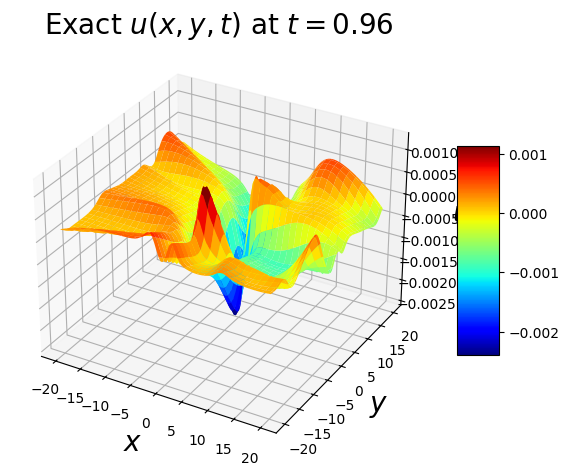

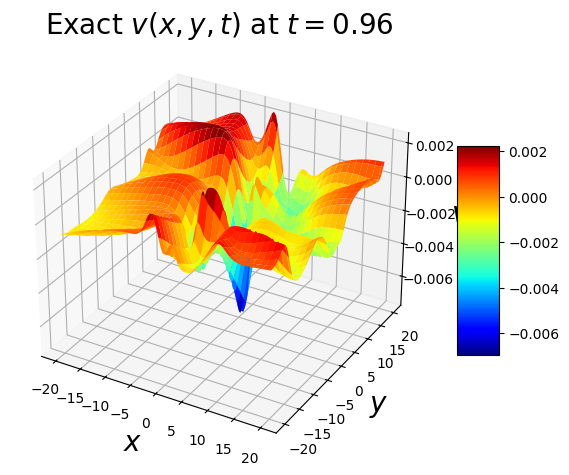

In [2]:
def draw_exact3d():
    predict_np = model.predict_U(x_test).cpu().detach().numpy()

    pred_u = np.reshape(predict_np[:, 0], (len(t), len(x), len(y)))
    pred_v = np.reshape(predict_np[:, 1], (len(t), len(x), len(y)))

    time_idx = 8

    # meshgrid for 3D plotting
    X, Y = np.meshgrid(x, y, indexing='ij')

    # Plot for pred_u
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, np.sin(0.5 * pred_u[time_idx, :, :]), cmap='jet')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$y$', fontsize=20)
    ax.set_zlabel('$u$', fontsize=20)
    ax.set_title(r'Exact $u(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('sg_u_exact_3d.jpg')
    plt.show()

    # Plot for pred_v
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, pred_v[time_idx, :, :], cmap='jet')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$y$', fontsize=20)
    ax.set_zlabel('$v$', fontsize=20)
    ax.set_title(r'Exact $v(x,y,t)$ at $t=%.2f$' % t[time_idx], fontsize=20)
    plt.tight_layout()
    plt.savefig('sg_v_exact_3d.jpg')
    plt.show()
draw_exact3d()